# 文件: chart_6_1.py

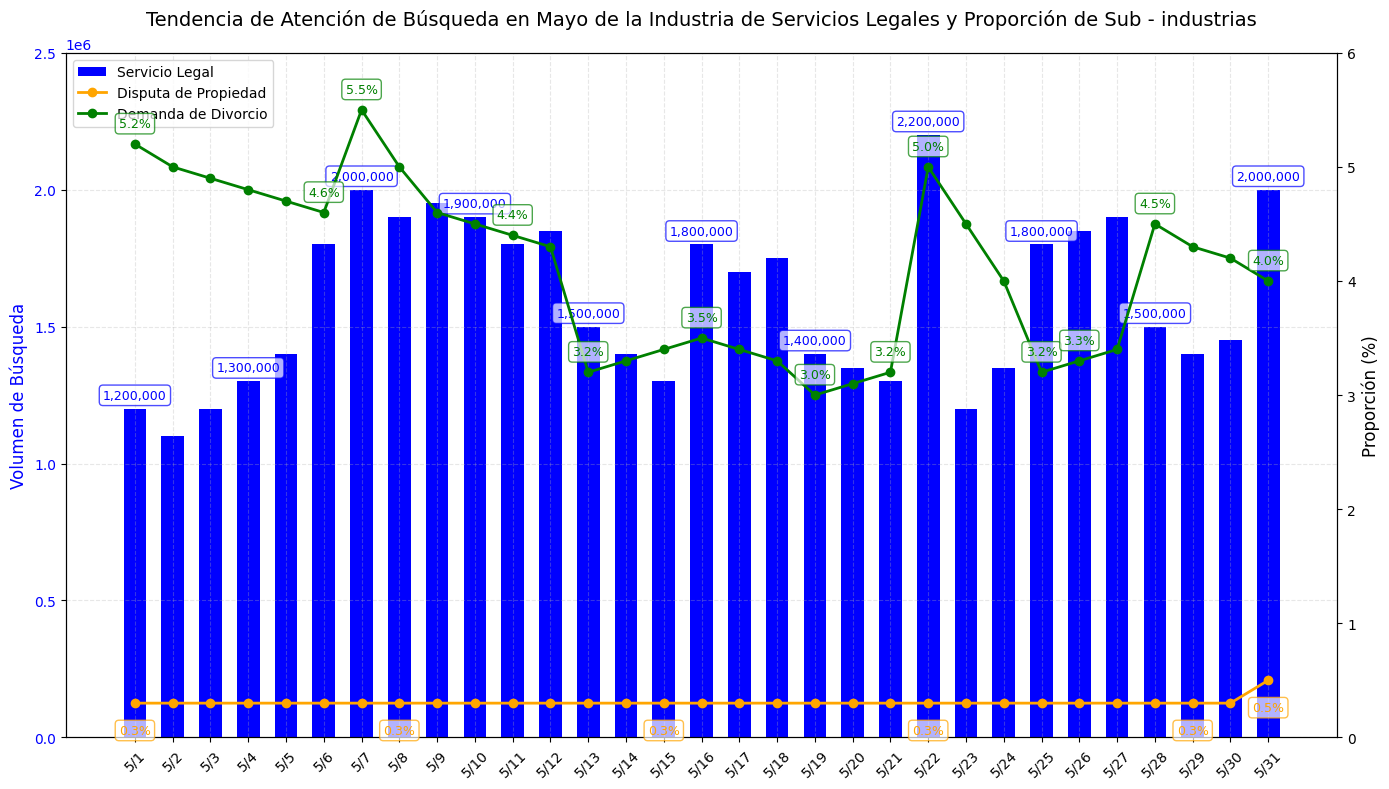

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# Lista de fechas
fechas = ["5/1", "5/2", "5/3", "5/4", "5/5", "5/6", "5/7", "5/8", "5/9", "5/10", 
          "5/11", "5/12", "5/13", "5/14", "5/15", "5/16", "5/17", "5/18", "5/19", 
          "5/20", "5/21", "5/22", "5/23", "5/24", "5/25", "5/26", "5/27", "5/28", 
          "5/29", "5/30", "5/31"]
# Volumen de búsqueda de servicios legales (gráfico de barras, eje izquierdo)
servicio_legal = [1200000, 1100000, 1200000, 1300000, 1400000, 1800000, 2000000, 
                  1900000, 1950000, 1900000, 1800000, 1850000, 1500000, 
                  1400000, 1300000, 1800000, 1700000, 1750000, 1400000, 
                  1350000, 1300000, 2200000, 1200000, 1350000, 1800000, 
                  1850000, 1900000, 1500000, 1400000, 1450000, 2000000]
# Lista de proporción de disputas de propiedad (aproximadamente %)
disputa_propiedad = [0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 
                     0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 
                     0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.5]
# Lista de proporción de demandas de divorcio (aproximadamente %)
demanda_divorcio = [5.2, 5.0, 4.9, 4.8, 4.7, 4.6, 5.5, 5.0, 4.6, 4.5, 
                    4.4, 4.3, 3.2, 3.3, 3.4, 3.5, 3.4, 3.3, 3.0, 3.1, 
                    3.2, 5.0, 4.5, 4.0, 3.2, 3.3, 3.4, 4.5, 4.3, 4.2, 4.0]

# Crear un lienzo y ejes dobles
fig, ax1 = plt.subplots(figsize=(14, 8))  # Eje primario (eje izquierdo)
ax2 = ax1.twinx()  # Eje secundario (eje derecho, proporción)

# Dibujar servicios legales (gráfico de barras, eje izquierdo)
x = np.arange(len(fechas))  # Índice de coordenadas X
barras = ax1.bar(x, servicio_legal, color='blue', label='Servicio Legal', width=0.6)
ax1.set_ylabel('Volumen de Búsqueda', color='blue', fontsize=12)
ax1.set_ylim(0, 2500000)  # Coincidir con el rango del eje izquierdo de la figura original
ax1.tick_params(axis='y', labelcolor='blue')

# Dibujar disputa de propiedad y demanda de divorcio (gráfico de líneas, eje derecho)
linea1, = ax2.plot(x, disputa_propiedad, color='orange', label='Disputa de Propiedad', marker='o', linestyle='-', linewidth=2)
linea2, = ax2.plot(x, demanda_divorcio, color='green', label='Demanda de Divorcio', marker='o', linestyle='-', linewidth=2)
ax2.set_ylabel('Proporción (%)', color='black', fontsize=12)
ax2.set_ylim(0, 6)  # Coincidir con el rango del eje derecho de la figura original (0% - 6%)
ax2.tick_params(axis='y', labelcolor='black')

# Configuración de las coordenadas X y la leyenda
ax1.set_xticks(x)
ax1.set_xticklabels(fechas, rotation=45, fontsize=10)  # Inclinar las fechas para evitar solapamiento
ax1.set_title('Tendencia de Atención de Búsqueda en Mayo de la Industria de Servicios Legales y Proporción de Sub - industrias', fontsize=14, pad=20)

# Agregar etiquetas de datos al gráfico de barras (volumen de búsqueda)
for i, barra in enumerate(barras):
    altura = barra.get_height()
    # Mostrar etiquetas cada 3 días para evitar sobrecrowding
    if i % 3 == 0:
        ax1.annotate(f'{altura:,}',
                     xy=(barra.get_x() + barra.get_width() / 2, altura),
                     xytext=(0, 5),  # Desplazamiento hacia arriba de 5 puntos
                     textcoords="offset points",
                     ha='center', va='bottom',
                     fontsize=9,
                     color='blue',
                     bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="blue", alpha=0.7))

# Agregar etiquetas de datos al gráfico de líneas de disputa de propiedad
for i, (x_val, y_val) in enumerate(zip(x, disputa_propiedad)):
    # Etiquetar solo puntos con cambios y nodos clave
    if y_val != 0.3 or i % 7 == 0 or i == len(x)-1:
        ax2.annotate(f'{y_val}%',
                     xy=(x_val, y_val),
                     xytext=(0, -15),  # Desplazamiento hacia abajo
                     textcoords="offset points",
                     ha='center', va='top',
                     fontsize=9,
                     color='orange',
                     bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="orange", alpha=0.7))

# Agregar etiquetas de datos al gráfico de líneas de demanda de divorcio
for i, (x_val, y_val) in enumerate(zip(x, demanda_divorcio)):
    # Etiquetar solo picos, valles y nodos clave
    if i == 0 or i == len(x)-1 or i % 5 == 0 or \
       (i > 0 and i < len(x)-1 and 
        (y_val > demanda_divorcio[i-1] and y_val > demanda_divorcio[i+1]) or 
        (y_val < demanda_divorcio[i-1] and y_val < demanda_divorcio[i+1])):
        ax2.annotate(f'{y_val}%',
                     xy=(x_val, y_val),
                     xytext=(0, 10),  # Desplazamiento hacia arriba
                     textcoords="offset points",
                     ha='center', va='bottom',
                     fontsize=9,
                     color='green',
                     bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="green", alpha=0.7))

# Combinar leyendas (mostrar leyendas de ejes dobles juntas)
lineas_1, etiquetas_1 = ax1.get_legend_handles_labels()
lineas_2, etiquetas_2 = ax2.get_legend_handles_labels()
ax1.legend(lineas_1 + lineas_2, etiquetas_1 + etiquetas_2, loc='upper left', fontsize=10)

# Agregar líneas de cuadrícula para mejorar la legibilidad
ax1.grid(True, linestyle='--', alpha=0.3)

# Optimizar el diseño
plt.tight_layout()
plt.show()

# 文件: chart_6_2.py

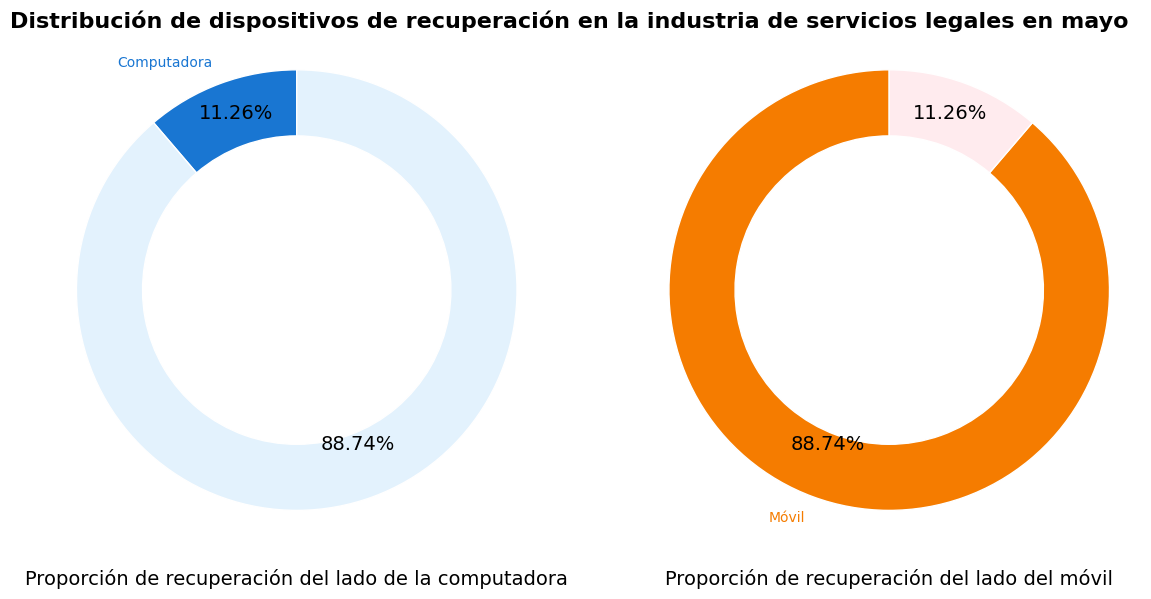

In [2]:
import matplotlib.pyplot as plt

# Datos
tamaños = [11.26, 88.74]

# Colores, más cercanos a la imagen original
colores_pc = ["#1976d2", "#e3f2fd"]  # Colores de la computadora: Azul oscuro y azul claro
colores_movil = ["#f57c00", "#ffebee"]  # Colores del móvil: Naranja y naranja claro

# Crear un lienzo y dos subgráficos
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
fig.subplots_adjust(top=0.85, bottom=0.15)  # Ajustar márgenes superior e inferior

# Dibujar el gráfico de proporción de recuperación del lado de la computadora (ajustar color de etiqueta)
wedges1, texts1, autotexts1 = ax1.pie(
    [tamaños[0], 100 - tamaños[0]],
    labels=["Computadora", ""],  # Simplificar etiquetas
    autopct=lambda p: f'{p:.2f}%\n' if p >= 3 else '',
    startangle=90,
    pctdistance=0.8,
    colors=colores_pc,
    wedgeprops=dict(width=0.3, edgecolor='w')
)

# Dibujar el gráfico de proporción de recuperación del lado del móvil (ajustar color de etiqueta)
wedges2, texts2, autotexts2 = ax2.pie(
    [tamaños[1], 100 - tamaños[1]],
    labels=["Móvil", ""],  # Simplificar etiquetas
    autopct=lambda p: f'{p:.2f}%\n' if p >= 3 else '',
    startangle=90,
    pctdistance=0.8,
    colors=colores_movil,
    wedgeprops=dict(width=0.3, edgecolor='w')
)

# Establecer colores de etiqueta (consistentes con los colores del gráfico circular correspondiente)
for text in texts1:
    text.set_color(colores_pc[0])  # Color de etiqueta de la computadora es azul oscuro
for text in texts2:
    text.set_color(colores_movil[0])  # Color de etiqueta del móvil es naranja oscuro

# Establecer el color del texto de porcentaje en negro
for text in autotexts1 + autotexts2:
    text.set_color('black')
    text.set_fontsize(14)

# Eliminar los ejes para que el gráfico sea un círculo perfecto
ax1.axis('equal')
ax2.axis('equal')

# Establecer subtítulos (debajo del gráfico)
ax1.text(0.5, -0.1, "Proporción de recuperación del lado de la computadora", 
         ha='center', va='center', transform=ax1.transAxes, fontsize=14)
ax2.text(0.5, -0.1, "Proporción de recuperación del lado del móvil", 
         ha='center', va='center', transform=ax2.transAxes, fontsize=14)

# Establecer el título principal
fig.suptitle("Distribución de dispositivos de recuperación en la industria de servicios legales en mayo", fontsize=16, fontweight='bold')

plt.tight_layout()  # Ajustar el diseño para evitar solapamiento
plt.show()

# 文件: chart_6_3.py

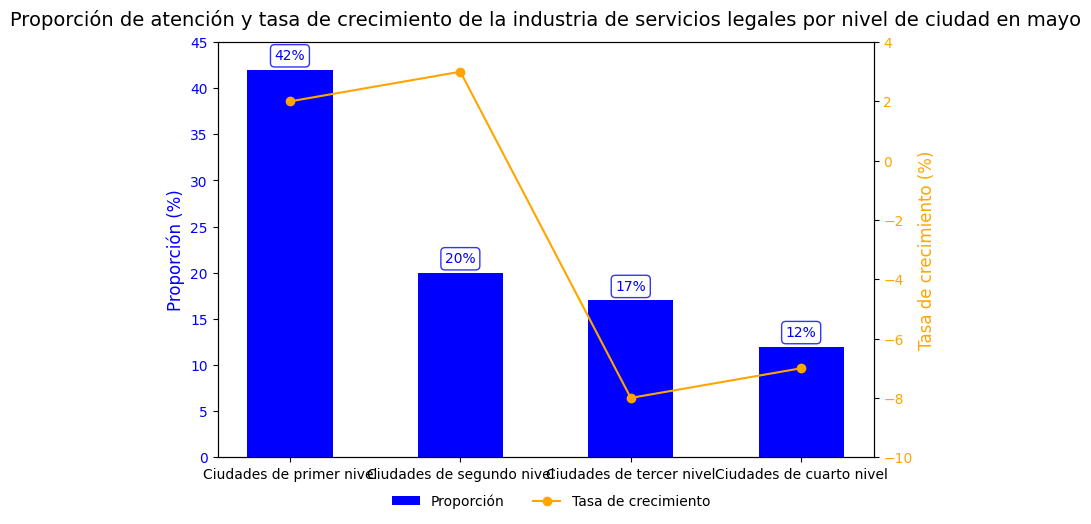

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# Definición de datos
categorias = ["Ciudades de primer nivel", "Ciudades de segundo nivel", "Ciudades de tercer nivel", "Ciudades de cuarto nivel"]
porcentajes = [42, 20, 17, 12]  # Datos de proporción
tazas_de_crecimiento = [2, 3, -8, -7]   # Datos de tasa de crecimiento

# Crear un lienzo y dos ejes Y
fig, ax1 = plt.subplots(figsize=(8, 5))
ax2 = ax1.twinx()

# Dibujar un gráfico de barras para las proporciones
x = np.arange(len(categorias))
barras = ax1.bar(
    x, porcentajes, 
    color="blue", 
    width=0.5, 
    label="Proporción"
)
ax1.set_ylabel("Proporción (%)", fontsize=12, color="blue")
ax1.set_ylim(0, 45)
ax1.tick_params(axis="y", labelcolor="blue")

# Dibujar un gráfico de línea para las tasas de crecimiento
ax2.plot(
    x, tazas_de_crecimiento, 
    color="orange", 
    marker="o", 
    label="Tasa de crecimiento"
)
ax2.set_ylabel("Tasa de crecimiento (%)", fontsize=12, color="orange")
ax2.set_ylim(-10, 4)
ax2.tick_params(axis="y", labelcolor="orange")

# Establecer las marcas y etiquetas del eje X
ax1.set_xticks(x)
ax1.set_xticklabels(categorias)

# Establecer el título
plt.title("Proporción de atención y tasa de crecimiento de la industria de servicios legales por nivel de ciudad en mayo", fontsize=14, y=1.02)

# Añadir etiquetas de datos de proporción al gráfico de barras (solo mantener las etiquetas de datos de barras)
for barra in barras:
    altura = barra.get_height()
    ax1.annotate(
        f'{altura}%',  # Mostrar el símbolo de porcentaje
        xy=(barra.get_x() + barra.get_width() / 2, altura),
        xytext=(0, 5),  # Desplazarse hacia arriba 5 puntos para evitar solapamiento con la parte superior de la barra
        textcoords="offset points",
        ha='center', va='bottom',
        fontsize=10,
        color='blue',  # Mismo color que el gráfico de barras para mejorar la relevancia
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="blue", alpha=0.8)  # Caja de fondo blanco para una visualización destacada
    )

# Ajustar la posición de la leyenda a la parte inferior del gráfico
fig.legend(
    loc="lower center", 
    bbox_to_anchor=(0.5, -0.05),
    ncol=2, 
    frameon=False
)

# Optimizar el diseño
plt.subplots_adjust(bottom=0.2)
plt.tight_layout()

# Mostrar el gráfico
plt.show()

# 文件: chart_6_4.py

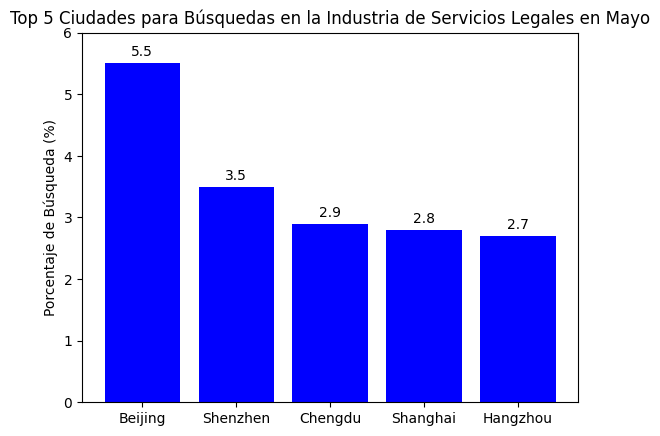

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# Nombres de las ciudades
ciudades = ['Beijing', 'Shenzhen', 'Chengdu', 'Shanghai', 'Hangzhou']
# Porcentajes de búsqueda correspondientes a cada ciudad (estimados según el gráfico, puedes reemplazarlos con datos precisos)
porcentajes = [5.5, 3.5, 2.9, 2.8, 2.7]  

x = np.arange(len(ciudades))  # Coordenadas del eje x

fig, ax = plt.subplots()
# Dibujar un gráfico de barras y establecer el color de las barras a azul
rects = ax.bar(x, porcentajes, color='blue')  

# Establecer las marcas y etiquetas del eje x
ax.set_xticks(x)
ax.set_xticklabels(ciudades)
# Establecer el rango del eje y
ax.set_ylim([0, 6])  
# Establecer las marcas del eje y
ax.set_yticks(np.arange(0, 7, 1))  
# Agregar un título al gráfico
ax.set_title('Top 5 Ciudades para Búsquedas en la Industria de Servicios Legales en Mayo')  
# Agregar una etiqueta al eje y
ax.set_ylabel('Porcentaje de Búsqueda (%)')  

# Anotar los valores en las barras (opcional, para hacer la información del gráfico más intuitiva)
for rect in rects:
    altura = rect.get_height()
    ax.annotate('{}'.format(altura),
                xy=(rect.get_x() + rect.get_width() / 2, altura),
                xytext=(0, 3),  # Distancia vertical de la anotación del valor desde la barra
                textcoords="offset points",
                ha='center', va='bottom')

plt.show()